In [18]:
from __future__ import annotations

import sys
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple , Dict, Optional, Sequence, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Make imports robust whether notebook runs from project root or labs/.
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = next((p for p in candidates if (p / 'labs' / 'day1_data_utils.py').exists()), Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

try:
    from data_utils import LoadedSeries, labels_to_ranges, load_generic_series_csv, load_nab_series
except ModuleNotFoundError:
    from data_utils import LoadedSeries, labels_to_ranges, load_generic_series_csv, load_nab_series

plt.style.use('default')


In [19]:
def build_synthetic_series(freq: str = '5min') -> LoadedSeries:
    n = 2000
    ts = pd.date_range('2024-01-01', periods=n, freq=freq)

    baseline = np.sin(np.linspace(0, 20 * np.pi, n)) * 0.2 + 1.0
    noise = np.random.normal(0, 0.05, size=n)
    values = baseline + noise

    # Injected anomalies
    values[400] += 2.0
    values[900:940] -= 0.6
    values[1400:1500] += np.linspace(0.0, 1.0, 100)

    series = pd.Series(values, index=ts, name='value')
    labels = pd.Series(False, index=ts)
    labels.iloc[400] = True
    labels.iloc[900:940] = True
    labels.iloc[1400:1500] = True

    return LoadedSeries(
        series=series,
        labels=labels,
        ranges=labels_to_ranges(labels),
        metadata={
            'dataset': 'synthetic',
            'source': 'generated',
            'n_points': n,
        },
    )


def read_data(
    dataset: str = 'synthetic',
    csv_path: str | None = None,
    nab_root: str = 'data/NAB',
    nab_series: str | None = None,
    nab_labels_path: str = 'labels/combined_windows.json',
) -> LoadedSeries:
    if dataset == 'synthetic':
        return build_synthetic_series()
    if dataset == 'csv':
        if not csv_path:
            raise ValueError('For dataset=csv, provide csv_path.')
        return load_generic_series_csv(csv_path)
    if dataset == 'nab':
        if not nab_series:
            raise ValueError('For dataset=nab, provide nab_series, e.g. realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv')
        return load_nab_series(nab_root=nab_root, series_relpath=nab_series, labels_path=nab_labels_path)
    raise ValueError(f'Unknown dataset: {dataset}')


In [20]:
loaded = read_data(dataset="synthetic")



series = loaded.series
labels = loaded.labels
truth_ranges = loaded.ranges

print('metadata:', loaded.metadata)
display(series.head())
display(labels.head())


metadata: {'dataset': 'synthetic', 'source': 'generated', 'n_points': 2000}


2024-01-01 00:00:00    0.951546
2024-01-01 00:05:00    1.125917
2024-01-01 00:10:00    1.073935
2024-01-01 00:15:00    0.930349
2024-01-01 00:20:00    1.019906
Freq: 5min, Name: value, dtype: float64

2024-01-01 00:00:00    False
2024-01-01 00:05:00    False
2024-01-01 00:10:00    False
2024-01-01 00:15:00    False
2024-01-01 00:20:00    False
Freq: 5min, dtype: bool

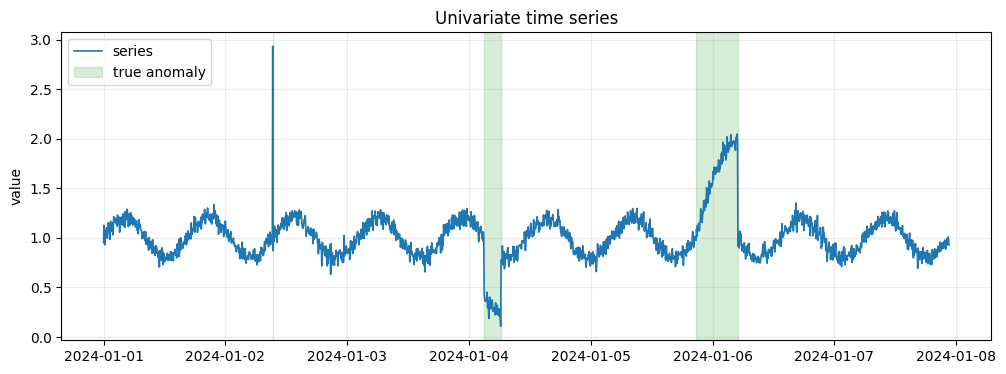

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series.index, series.values, color='tab:blue', linewidth=1.2, label='series')

for i, (start, end) in enumerate(truth_ranges):
    ax.axvspan(start, end, color='tab:green', alpha=0.18, label='true anomaly' if i == 0 else None)

ax.set_title('Univariate time series')
ax.set_ylabel('value')
ax.grid(alpha=0.25)
ax.legend(loc='upper left')
plt.show()


In [22]:

def rolling_zscore(series: pd.Series, window: int = 48) -> pd.Series:
    mean = series.rolling(window=window, min_periods= max(5, window//4)).mean()
    std = series.rolling(window=window, min_periods= max(5, window//4)).std(ddof=0) # N-1 in division 
    z = (series - mean) / (std + 1e-12)
    return z.abs().fillna(0.0)

def mad_score(series: pd.Series, window: int = 48) -> pd.Series:
    med = series.rolling(window=window, min_periods=max(5,window // 4)).median()
    mad = series.rolling(window, min_periods=max(5,window//4)).apply(
        lambda x: np.median(np.abs(x-np.median(x))),
        raw=True,
    )
    z = 0.6745 * (series - med ) / (mad + 1e-12)
    return z.abs().fillna(0.0)

def stl_residual_scores(series: pd.Series, period: int = 288) -> pd.Series:
    eff_period = min(max(2, int(period)), max(2, len(series) - 1))
    res = STL(series, period = eff_period).fit()
    resid = pd.Series(res.resid, index = series.index)
    return (resid.abs() / (resid.std() + 1e-12)).fillna(0.0)


def cusum_scores(series: pd.Series, drift: float = 0.0) -> pd.Series:
    s_pos = np.zeros_like(series.values, dtype=float)
    s_neg = np.zeros_like(series.values, dtype=float)
    scores = np.zeros_like(series.values, dtype=float)
    for i in range(1, len(series)):
        diff = series.iloc[i] - series.iloc[i - 1] - drift
        s_pos[i] = max(0, s_pos[i - 1] + diff)
        s_neg[i] = min(0, s_neg[i - 1] + diff)
        scores[i] = max(s_pos[i], -s_neg[i])
    return pd.Series(scores, index=series.index)





# Isolation Forest

**Lernziel:** Sie bilden aus der Reihe Lag- und Rolling-Feature-Vektoren und trainieren einen `IsolationForest` (mit `StandardScaler`) auf dem ersten Datenteil. Der Forest liefert einen modellbasierten Anomalie-Score als Ergänzung zu den statistischen Detektoren. Achtung: Der Scaler ist empfindlich gegenüber Ausreißern.

In [23]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler # be careful with Scaler ! (very sensitive)

def make_features(series, lags, windows):
    """Features = lags + rolling statistics"""
    
    data = pd.DataFrame(index=series.index)
    for lag in lags:
        data[f"lag_{lag}"] = series.shift(lag) # value at series[i-lag]
    for w in windows:
        data[f"roll_mean_{w}"] = series.rolling(w, min_periods = 5).mean()
        data[f"roll_std_{w}"] = series.rolling(w, min_periods = 5).std(ddof = 0)
        data[f"roll_median_{w}"] = series.rolling(w, min_periods = 5).median() 
    data["value"] = series.values
    data = data.dropna()
    return data

def train_if(train, contamination = 0.01):
    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("iforest", IsolationForest(n_estimators=200,contamination=contamination,random_state=1)),
        ]
    )
    model.fit(train)
    return model 

def if_scores(model, input):
    # decision_function: higher = more normal, lower = more anomalous.
    # Negate -> higher = more anomalous, then standardize so the baseline sits
    # near 0 and anomalies show up as positive z-spikes (same convention as the
    # statistical detectors above; the mu+3*sigma threshold becomes ~3 sigma).
    raw = -pd.Series(model.decision_function(input), index=input.index)
    return (raw - raw.mean()) / (raw.std() + 1e-12)


features = make_features(series, lags=[1,2,3,6,12,24], windows=[6,12,24,48])
train,val = train_test_split(features, shuffle=False, train_size=0.6)
if_model = train_if(train)
if_scores(if_model,features)

2024-01-01 02:00:00   -0.345853
2024-01-01 02:05:00   -0.221790
2024-01-01 02:10:00   -0.240316
2024-01-01 02:15:00   -0.250759
2024-01-01 02:20:00   -0.510203
                         ...   
2024-01-07 22:15:00   -0.403717
2024-01-07 22:20:00   -0.293366
2024-01-07 22:25:00   -0.395950
2024-01-07 22:30:00   -0.446747
2024-01-07 22:35:00   -0.432457
Freq: 5min, Length: 1976, dtype: float64

## Score, Schwellenwert und Alarme visualisieren

**Lernziel:** Sie wählen einen Score (hier den DTW-Matrix-Profile-Template-Score), setzen einen Schwellenwert (z. B. $\mu + 3\sigma$) und markieren alle Punkte oberhalb als Alarme. So sehen Sie, wo der Detektor anschlägt und ob er die wahren Anomaliefenster trifft.

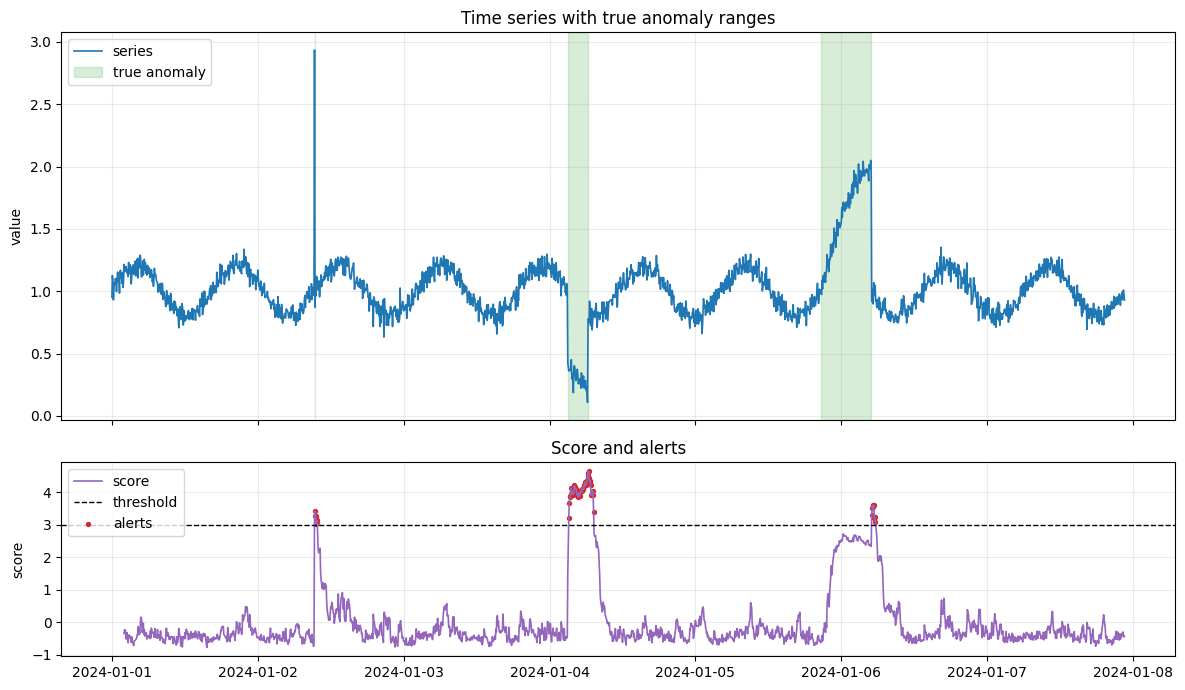

In [25]:
def plot_series_with_score(
    series: pd.Series,
    scores: pd.Series,
    truth_ranges: List[Tuple[pd.Timestamp, pd.Timestamp]],
    threshold: float,
) -> pd.Series:
    scores = scores.reindex(series.index)
    alerts = scores >= threshold

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    axes[0].plot(series.index, series.values, color='tab:blue', linewidth=1.2, label='series')
    for i, (start, end) in enumerate(truth_ranges):
        axes[0].axvspan(start, end, color='tab:green', alpha=0.18, label='true anomaly' if i == 0 else None)
    axes[0].set_title('Time series with true anomaly ranges')
    axes[0].set_ylabel('value')
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc='upper left')

    axes[1].plot(scores.index, scores.values, color='tab:purple', linewidth=1.2, label='score')
    axes[1].axhline(threshold, color='black', linestyle='--', linewidth=1.0, label='threshold')
    axes[1].scatter(scores.index[alerts], scores[alerts], s=8, color='tab:red', label='alerts')
    axes[1].set_title('Score and alerts')
    axes[1].set_ylabel('score')
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc='upper left')

    plt.tight_layout()
    plt.show()
    return alerts


# Placeholder score for plotting workflow only
#score_z= dtw_mp_template_score(series, m=50)
score_z = if_scores(if_model,features)
mean_s = score_z.mean()
std_s = score_z.std()
threshold = mean_s + 3*std_s # mu + 3*std 
#threshold = score_z.loc[val.index].quantile(0.98)
#print(threshold)
alerts = plot_series_with_score(series, score_z, truth_ranges, threshold)




In [ ]:
score_z.std()

np.float64(10.744903117973733)

## Evaluation: Punktmetriken und Precision@k

**Lernziel:** Sie bewerten die Alarme quantitativ. `point_metrics` liefert Precision/Recall/F1 punktweise. `precision_at_k` misst, welcher Anteil der k höchstbewerteten Punkte tatsächlich in einem wahren Anomaliebereich liegt (diese Lücke füllen Sie aus).

In [ ]:
def point_metrics(pred: pd.Series, truth: pd.Series) -> dict:
    pred_b = pred.astype(bool)
    truth_b = truth.astype(bool)

    tp = int((pred_b & truth_b).sum())
    fp = int((pred_b & ~truth_b).sum())
    fn = int((~pred_b & truth_b).sum())
    tn = int((~pred_b & ~truth_b).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }


def precision_at_k(
    scores: pd.Series,
    truth_ranges: List[Tuple[pd.Timestamp, pd.Timestamp]],
    k: int = 50,
) -> float:
    if len(truth_ranges) == 0:
        return float('nan')
    top_idx = scores.nlargest(min(k, len(scores))).index
    hits = sum(any(start <= ts <= end for start, end in truth_ranges) for ts in top_idx)
    return hits / max(min(k, len(scores)), 1)


In [ ]:
m = point_metrics(alerts, labels)
p_at_50 = precision_at_k(score_z, truth_ranges, k=50)

print('Point metrics:', m)
print('Precision@50:', round(p_at_50, 4))


Point metrics: {'tp': 27, 'fp': 49, 'fn': 114, 'tn': 1810, 'precision': 0.35526315789473684, 'recall': 0.19148936170212766, 'f1': 0.24884792626728106}
Precision@50: 0.02
